In [ ]:
# Что нужно сделать:
# Предсказать, уйдет ли клиент из сервиса. Сфера может быть любая, например: банк, телеком, подписочный сервис.

# Как это можно сделать:
# ▪️ Использовать признаки: время в сервисе, частота операций, обращения в поддержку, возраст
# ▪️ Учитывать дисбаланс классов используя F1, ROC-AUC
# ▪️ Попробовать: Logistic Regression, Random Forest, CatBoost
# ▪️ Добавить важность признаков для объяснения бизнесу

In [12]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# Показывает долю каждого класса в процентах, так мы увидели, что есть дисбаланс классов 
print(df["Churn"].value_counts(normalize=True)) # в процентах
print(df['Churn'].value_counts()) # в количестве

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Удаляем ненужный ID, он не несет смысла для обучения
df = df.drop(columns=["customerID"], errors='ignore')
y = df["Churn"].map({"Yes":1, "No": 0}) #перевели таргет в 0-остались и 1-ушли

#переводим в числа и чистим пропуски
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") #errors="coerce" превращает "" в NaN и не выдает ошибку
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

#Выбрасываем таргет из признаков, чтобы модель не училась сама на себе
X = df.drop(columns=["Churn"])

#переводим все текст. категории в 0 и 1
# drop_first=True удаляет одну лишнюю колонку, чтобы не было мультиколлинеарности
X = pd.get_dummies(X, drop_first=True)

#делим на train/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model1 = LogisticRegression(max_iter=1000)
log_model1.fit(X_train, y_train)
y_pred_log1 = log_model1.predict_proba(X_test)[:, 1]
y_pred_class1 = (y_pred_log1 >= 0.5).astype(int)

print(classification_report(y_test, y_pred_class1))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



C:\Users\User\PycharmProjects\pythonProject7\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
#тут мы получаем ошибку, что модель не хватает 1000 шагов, чтобы подобрать идеальные веса
#потому что в датасете есть 3 числовых признака с разными масштабами

#tenure (время) — измеряется единицами (от 0 до 72 месяцев).
#MonthlyCharges — измеряется десятками и сотнями (от 18 до 118 долларов).
#TotalCharges — измеряется тысячами (до 8000+ долларов).

#применяем масштабирование
#выбираем колонки, которые реально нужно отмасштабировать
nums_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[nums_cols] = scaler.fit_transform(X_train[nums_cols])
X_test_scaled[nums_cols] = scaler.transform(X_test[nums_cols])

#вот теперь обуч лог регр

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict_proba(X_test_scaled)[:, 1]
y_pred_class = (y_pred_log >= 0.5).astype(int)

print(classification_report(y_test, y_pred_class))


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [34]:
import pandas as pd
import numpy as np

# Превращаем в массивы NumPy
actual = y_test.values
predicted = y_pred_class

tp = ((actual == 1) & (predicted == 1)).sum() # Предсказано: Ушел (1) | Реально: Ушел (1)
fp = ((actual == 0) & (predicted == 1)).sum() # Предсказано: Ушел (1) | Реально: Остался (0)
fn = ((actual == 1) & (predicted == 0)).sum() # Предсказано: Остался (0) | Реально: Ушел (1)
tn = ((actual == 0) & (predicted == 0)).sum() # Предсказано: Остался (0) | Реально: Остался (0)

# Собираем DataFrame строго по схеме: слева Предсказано (+/-), сверху Реально (+/-)
my_confusion_matrix = pd.DataFrame(
    data=[[tp, fp], 
          [fn, tn]],
    index=['Предсказано: Ушли (+)', 'Предсказано: Остались (-)'],
    columns=['Реально: Ушли (+)', 'Реально: Остались (-)']
)

# Выводим красивую таблицу
print("=== МАТРИЦА ОШИБОК ===")
display(my_confusion_matrix)

=== МАТРИЦА ОШИБОК ===


,Реально: Ушли (+),Реально: Остались (-)
Предсказано: Ушли (+),224,102
Предсказано: Остались (-),149,934


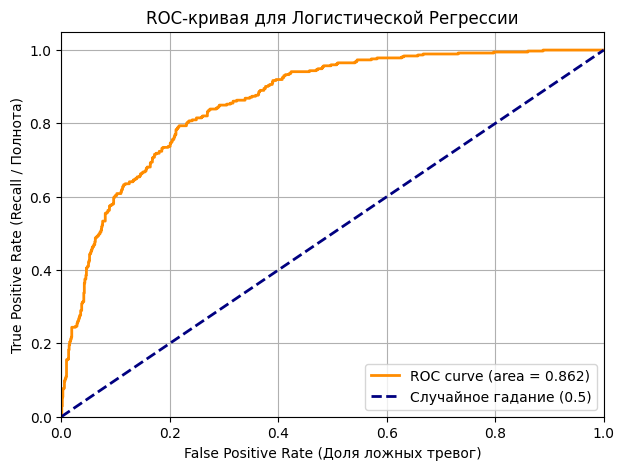

Итоговый показатель ROC-AUC: 0.8622


In [35]:
#считаем roc-auc
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Считаем сам показатель ROC-AUC (передаем реальные 0/1 и сырые вероятности класса 1)
auc_value = roc_auc_score(y_test, y_pred_log)

# 2. Получаем точки для построения кривой (False Positive Rate, True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_log)

# 3. Строим график
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_value:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайное гадание (0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Доля ложных тревог)')
plt.ylabel('True Positive Rate (Recall / Полнота)')
plt.title('ROC-кривая для Логистической Регрессии')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Итоговый показатель ROC-AUC: {auc_value:.4f}")


In [ ]:
#Модель отлично разделяет людей. Показатель 0.86 означает, что если мы случайно возьмем 
#одного реального беглеца (отток) 
# и одного лояльного клиента, то наша модель с вероятностью 85% присвоит уходящему 
#клиенту более высокий балл риска, чем лояльному. 
# Это говорит о том, что логистическая регрессия 
# успешно нашла скрытые закономерности в данных.

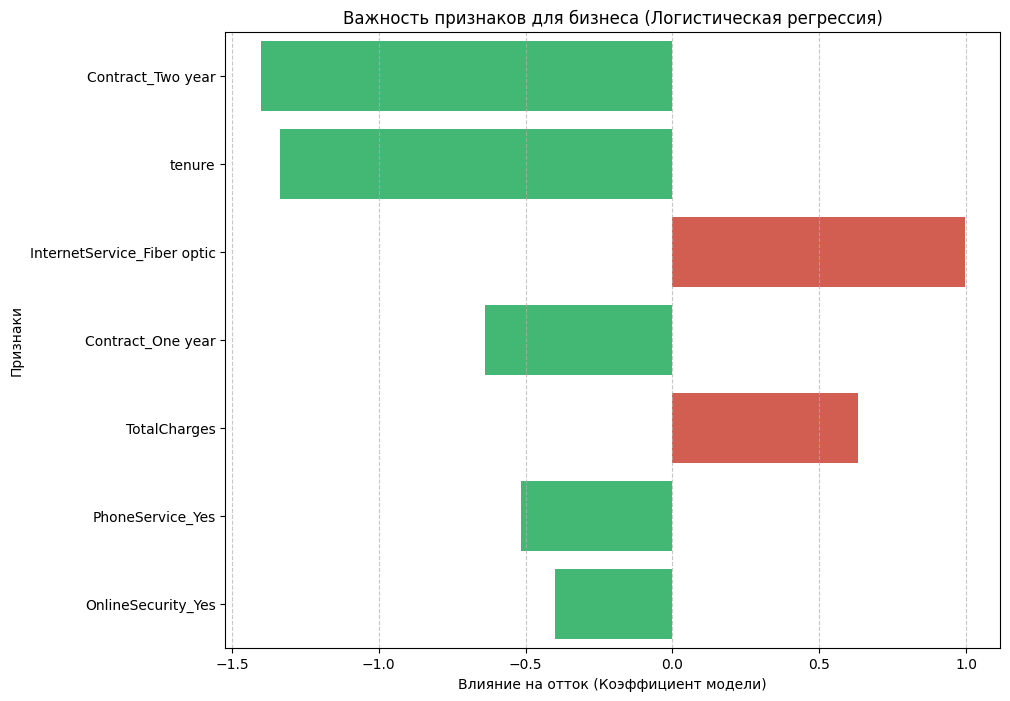

In [38]:
#проверяем важность признаков:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Вытаскиваем веса модели (они лежат в первом элементе массива coef_)
weights = log_model.coef_[0]

# 2. Собираем DataFrame: название признака и его вес
importance_df = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность (Вес)': weights
})

# 3. Сортируем по абсолютному значению (нам важна сила влияния в любую сторону)
importance_df['Абсолютное значение'] = importance_df['Важность (Вес)'].abs()
importance_df = importance_df.sort_values(by='Абсолютное значение', ascending=False).drop(columns=['Абсолютное значение'])

importance_df = importance_df.head(7) # оставляем только 7 самых значимых факторов

# 4. Строим красивый горизонтальный график
plt.figure(figsize=(10, 8))
# Настраиваем цвет: пусть положительные веса будут красными (стимул оттока), а отрицательные — зелеными (удержание)
colors = ['#e74c3c' if w > 0 else '#2ecc71' for w in importance_df['Важность (Вес)']]

sns.barplot(x='Важность (Вес)', y='Признак', data=importance_df, hue='Признак', palette=colors, legend=False)
plt.title('Важность признаков для бизнеса (Логистическая регрессия)')
plt.xlabel('Влияние на отток (Коэффициент модели)')
plt.ylabel('Признаки')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [60]:
#теперь перейдем к след модели: Random Forest
#увеличится ли ROC-AUC?

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_score_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_score_rf)

print(roc_auc_rf)
print(classification_report(y_test, y_pred_rf))

0.8665844607533615
              precision    recall  f1-score   support

           0       0.93      0.73      0.82      1036
           1       0.53      0.85      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.79      0.73      1409
weighted avg       0.82      0.76      0.77      1409



In [73]:
from catboost import CatBoostClassifier

cb_model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=5,
    auto_class_weights='Balanced', #удерживаем баланс классов
    random_seed=42,
    verbose=100 # Выводить отчет о ходе обучения каждые 100 итераций
)
cb_model.fit(X_train, y_train)

# Делаем предсказания
y_pred_cb = cb_model.predict(X_test)
y_score_cb = cb_model.predict_proba(X_test)[:, 1]

# Считаем финальный ROC-AUC
auc_cb = roc_auc_score(y_test, y_score_cb)
print(f"\nИтоговый ROC-AUC для CatBoost: {auc_cb:.4f}")

print("\n=== ОТЧЕТ ПО КЛАССИФИКАЦИИ (CATBOOST) ===")
print(classification_report(y_test, y_pred_cb))


0:	learn: 0.6801175	total: 6.71ms	remaining: 4.02s
100:	learn: 0.4813671	total: 542ms	remaining: 2.68s
200:	learn: 0.4653195	total: 1.1s	remaining: 2.19s
300:	learn: 0.4552102	total: 1.62s	remaining: 1.61s
400:	learn: 0.4439533	total: 2.19s	remaining: 1.09s
500:	learn: 0.4335168	total: 2.79s	remaining: 551ms
599:	learn: 0.4242913	total: 3.21s	remaining: 0us

Итоговый ROC-AUC для CatBoost: 0.8630

=== ОТЧЕТ ПО КЛАССИФИКАЦИИ (CATBOOST) ===
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.54      0.83      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.79      0.74      1409
weighted avg       0.82      0.77      0.78      1409



In [76]:
#генерация фичей Feature Engineering

#добавим несколько признаков:

#AverageMonthlyCharges - Средний чек за месяц реальности
#LongTermContract - Наличие долгосрочного контракта
#StreamingServicesCount - Количество стриминговых услуг
#SecurityServicesCount - Пакет безопасности
#TotalServices - Всего подключенных услуг

def feature_engineering(df_input):
    df = df_input.copy()
    # Защита от деления на ноль: если tenure == 0, заменим на 1
    safe_tenure = df["tenure"].replace(0, 1)
    # Средний исторический чек в месяц
    df["AverageMonthlyCharges"] = df["TotalCharges"] / safe_tenure
    # Изменение чека: насколько текущий чек выше или ниже среднего исторического
    #df["ChargesDeviation"] = df["MonthlyCharges"] - df["AverageMonthlyCharges"]
    #Долгосрочный контракт (1 - да, 0 - помесячный)
    df["LongTermContract"] = df["Contract"].apply(
        lambda x: 0 if x == "Month-to-month" else 1
    )
    
    services = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
    ]
    # Считаем, сколько раз у клиента стоит 'Yes' по этим сервисам
    df["ServicesCount"] = (df[services] == "Yes").sum(axis=1)

    # 4. Отдельно стриминговый пакет (якорь для развлечений)
    df["StreamingCount"] = (
        df[["StreamingTV", "StreamingMovies"]] == "Yes"
    ).sum(axis=1)

    # 5. Отдельно пакет безопасности
    df["SecurityCount"] = (
        df[["OnlineSecurity", "OnlineBackup"]] == "Yes"
    ).sum(axis=1)

    return df

df_enhanced = feature_engineering(df)
print(f"Было признаков: {df.shape[1]}")
print(f"Стало признаков после Feature Engineering: {df_enhanced.shape[1]}")

Было признаков: 20
Стало признаков после Feature Engineering: 25


In [79]:
#прогоняем новый датасет через Catboost

# Из нового датасета убираем таргет и ID, чтобы получить чистые фичи
X = df_enhanced.drop(columns=['Churn', 'customerID'], errors='ignore')
y = df_enhanced['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    #stratify=y гарантирует, что дисбаланс классов в трейне и тесте
)

cat_features = list(X.select_dtypes(include=['object', 'category']).columns)

# Создаем модель с нашими крутыми настройками против переобучения
cb_enhanced = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=5,
    auto_class_weights='Balanced',
    random_seed=42,
    cat_features=cat_features, # Передаем список текстовых колонок сюда!
    verbose=100
)

# Обучаем модель на новых признаках
cb_enhanced.fit(X_train, y_train)

# Делаем предсказания
y_pred_cb = cb_enhanced.predict(X_test)
y_score_cb = cb_enhanced.predict_proba(X_test)[:, 1]

# Считаем и выводим обновленный ROC-AUC
auc_cb_enhanced = roc_auc_score(y_test, y_score_cb)
print(f"\n ОБНОВЛЕННЫЙ ROC-AUC после Feature Engineering: {auc_cb_enhanced:.4f}")

print("ОТЧЕТ ПО КЛАССИФИКАЦИИ")
print(classification_report(y_test, y_pred_cb))

0:	learn: 0.6737320	total: 52.5ms	remaining: 26.2s
100:	learn: 0.4406422	total: 3.3s	remaining: 13s
200:	learn: 0.4119316	total: 6.31s	remaining: 9.39s
300:	learn: 0.3780496	total: 9.82s	remaining: 6.49s
400:	learn: 0.3463683	total: 13.5s	remaining: 3.34s
499:	learn: 0.3239576	total: 17.1s	remaining: 0us

 ОБНОВЛЕННЫЙ ROC-AUC после Feature Engineering: 0.8407
ОТЧЕТ ПО КЛАССИФИКАЦИИ
              precision    recall  f1-score   support

          No       0.90      0.78      0.83      1035
         Yes       0.55      0.75      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409

